# Loading Library, DATA and Mapping format

### Librarby

In [3]:
#!/usr/bin/env python3
"""
================================================================================
GROUPED FEATURE ANALYSIS: BY INSTRUMENT AND PARAMETER TYPE
================================================================================

Feature Structure:
- No index (base)  = Vocal   : Hum, Hiss, CL, Thre, Ratio, Attk, Release
- Index 1          = Drum    : Hum1, Hiss1, CL1, Thre1, Ratio1, Attk1, Release1
- Index 2          = Bass    : Hum2, Hiss2, CL2, Thre2, Ratio2, Attk2, Release2
- Index 3          = Guitar  : Hum3, Hiss3, CL3, Thre3, Ratio3, Attk3, Release3

Analysis:
1. Aggregate importance by Instrument
2. Aggregate importance by Parameter Type
3. Instrument × Parameter heatmap
4. Cross-codec comparison at grouped level

================================================================================
"""

import pandas as pd
import numpy as np
from scipy import stats
from sklearn.model_selection import cross_val_score, RepeatedKFold
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.style.use('seaborn-v0_8-whitegrid')




### Feature Mapping

In [4]:
# Define the mapping
INSTRUMENTS = {
    'Vocal': ['Hum', 'Hiss', 'CL', 'Thre', 'Ratio', 'Attk', 'Release'],
    'Drum': ['Hum1', 'Hiss1', 'CL1', 'Thre1', 'Ratio1', 'Attk1', 'Release1'],
    'Bass': ['Hum2', 'Hiss2', 'CL2', 'Thre2', 'Ratio2', 'Attk2', 'Release2'],
    'Guitar': ['Hum3', 'Hiss3', 'CL3', 'Thre3', 'Ratio3', 'Attk3', 'Release3']
}

PARAM_TYPES = {
    'Hum': ['Hum', 'Hum1', 'Hum2', 'Hum3'],
    'Hiss': ['Hiss', 'Hiss1', 'Hiss2', 'Hiss3'],
    'CL': ['CL', 'CL1', 'CL2', 'CL3'],
    'Thre': ['Thre', 'Thre1', 'Thre2', 'Thre3'],
    'Ratio': ['Ratio', 'Ratio1', 'Ratio2', 'Ratio3'],
    'Attk': ['Attk', 'Attk1', 'Attk2', 'Attk3'],
    'Release': ['Release', 'Release1', 'Release2', 'Release3']
}

# Create reverse mapping: feature -> (instrument, param_type)
feature_to_group = {}
for inst, features in INSTRUMENTS.items():
    for feat in features:
        feature_to_group[feat] = {'instrument': inst}

for ptype, features in PARAM_TYPES.items():
    for feat in features:
        feature_to_group[feat]['param_type'] = ptype

print("\nFeature Mapping:")
print("-" * 50)
print(f"{'Feature':<12} {'Instrument':<12} {'Param Type':<12}")
print("-" * 50)
for feat, groups in feature_to_group.items():
    print(f"{feat:<12} {groups['instrument']:<12} {groups['param_type']:<12}")



Feature Mapping:
--------------------------------------------------
Feature      Instrument   Param Type  
--------------------------------------------------
Hum          Vocal        Hum         
Hiss         Vocal        Hiss        
CL           Vocal        CL          
Thre         Vocal        Thre        
Ratio        Vocal        Ratio       
Attk         Vocal        Attk        
Release      Vocal        Release     
Hum1         Drum         Hum         
Hiss1        Drum         Hiss        
CL1          Drum         CL          
Thre1        Drum         Thre        
Ratio1       Drum         Ratio       
Attk1        Drum         Attk        
Release1     Drum         Release     
Hum2         Bass         Hum         
Hiss2        Bass         Hiss        
CL2          Bass         CL          
Thre2        Bass         Thre        
Ratio2       Bass         Ratio       
Attk2        Bass         Attk        
Release2     Bass         Release     
Hum3         Guitar   

### Loading Data

In [5]:
# =============================================================================
# DATA LOADING
# =============================================================================
print("\n" + "="*70)
print("LOADING DATA")
print("="*70)

mp3_df = pd.read_csv("./data/RL_Data_FullResults_202511281950_mp3.csv")
aac_df = pd.read_csv("./data/RL_Data_FullResults_202512051033_aac.csv")
nc_df = pd.read_csv("./data/RL_Data_FullResults_202512111058_nc.csv")

# Standardize rewards
for df in [mp3_df, aac_df, nc_df]:
    df['reward_std'] = (df['reward'] - df['reward'].mean()) / df['reward'].std()

datasets = {'MP3': mp3_df, 'AAC': aac_df, 'NC': nc_df}
feature_cols = [col for col in mp3_df.columns if col not in ['reward', 'reward_std']]

print(f"Features: {len(feature_cols)}")
print(f"Instruments: {list(INSTRUMENTS.keys())}")
print(f"Parameter Types: {list(PARAM_TYPES.keys())}")


LOADING DATA
Features: 28
Instruments: ['Vocal', 'Drum', 'Bass', 'Guitar']
Parameter Types: ['Hum', 'Hiss', 'CL', 'Thre', 'Ratio', 'Attk', 'Release']


# Prepare the XGBOOST MODEL

In [6]:
# =============================================================================
# XGBOOST MODEL CONFIGURATION
# =============================================================================
xgb_params = {
    'n_estimators': 100,
    'max_depth': 6,
    'learning_rate': 0.1,
    'min_child_weight': 3,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'verbosity': 0,
    'base_score': 0.5
}

In [7]:
# =============================================================================
# COMPUTE PERMUTATION IMPORTANCE FOR EACH CODEC
# =============================================================================

importance_by_codec = {}

for codec_name, df in datasets.items():
#    print(f"\n{codec_name}...")
    X = df[feature_cols].values
    y = df['reward_std'].values
    
    model = XGBRegressor(**xgb_params)
    model.fit(X, y)
    
    # Permutation importance
    perm_result = permutation_importance(
        model, X, y, n_repeats=30, random_state=RANDOM_STATE, n_jobs=-1, scoring='r2'
    )
    
    importance_by_codec[codec_name] = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': perm_result.importances_mean,
        'Std': perm_result.importances_std
    })
    


MP3...

AAC...

NC...


# Data Feature Process

## AGGREGATE BY INSTRUMENT

In [8]:
instrument_importance = {}

for codec_name, imp_df in importance_by_codec.items():
    inst_imp = {}
    for inst, features in INSTRUMENTS.items():
        # Sum importance of all features belonging to this instrument
        mask = imp_df['Feature'].isin(features)
        inst_imp[inst] = imp_df.loc[mask, 'Importance'].sum()
    instrument_importance[codec_name] = inst_imp

inst_df = pd.DataFrame(instrument_importance)
inst_df_norm = inst_df.div(inst_df.sum(axis=0), axis=1)  # Normalize

print("\nRaw Importance by Instrument:")
print(inst_df.round(4).to_string())

print("\nNormalized Importance (% of total):")
print((inst_df_norm * 100).round(2).to_string())

# Rank by instrument
print("\nInstrument Rankings by Codec:")
inst_ranks = inst_df.rank(ascending=False).astype(int)
print(inst_ranks.to_string())


Raw Importance by Instrument:
           MP3     AAC      NC
Vocal   0.5703  0.3433  0.3086
Drum    0.8397  0.3995  0.7261
Bass    0.3479  0.1404  0.1421
Guitar  0.1948  0.0935  0.1297

Normalized Importance (% of total):
          MP3    AAC     NC
Vocal   29.21  35.15  23.62
Drum    43.00  40.91  55.58
Bass    17.82  14.37  10.88
Guitar   9.98   9.57   9.93

Instrument Rankings by Codec:
        MP3  AAC  NC
Vocal     2    2   2
Drum      1    1   1
Bass      3    3   3
Guitar    4    4   4


## AGGREGATE BY Degradation TYPE

In [9]:
param_importance = {}

for codec_name, imp_df in importance_by_codec.items():
    param_imp = {}
    for ptype, features in PARAM_TYPES.items():
        mask = imp_df['Feature'].isin(features)
        param_imp[ptype] = imp_df.loc[mask, 'Importance'].sum()
    param_importance[codec_name] = param_imp

param_df = pd.DataFrame(param_importance)
param_df_norm = param_df.div(param_df.sum(axis=0), axis=1)

print("\nRaw Importance by Parameter Type:")
print(param_df.round(4).to_string())

print("\nNormalized Importance (% of total):")
print((param_df_norm * 100).round(2).to_string())

# Rank by parameter type
print("\nParameter Type Rankings by Codec:")
param_ranks = param_df.rank(ascending=False).astype(int)
print(param_ranks.to_string())


Raw Importance by Parameter Type:
            MP3     AAC      NC
Hum      0.7317  0.3552  0.5000
Hiss     0.5270  0.2542  0.3482
CL       0.2078  0.0555  0.0336
Thre     0.2254  0.1928  0.1207
Ratio    0.1908  0.0793  0.2709
Attk     0.0550  0.0341  0.0149
Release  0.0149  0.0056  0.0182

Normalized Importance (% of total):
           MP3    AAC     NC
Hum      37.47  36.37  38.27
Hiss     26.99  26.03  26.65
CL       10.64   5.69   2.57
Thre     11.54  19.74   9.24
Ratio     9.77   8.12  20.74
Attk      2.82   3.49   1.14
Release   0.77   0.57   1.39

Parameter Type Rankings by Codec:
         MP3  AAC  NC
Hum        1    1   1
Hiss       2    2   2
CL         4    5   5
Thre       3    3   4
Ratio      5    4   3
Attk       6    6   7
Release    7    7   6


## INSTRUMENT × PARAMETER TYPE MATRIX

In [10]:
# =============================================================================
# INSTRUMENT × PARAMETER TYPE MATRIX
# =============================================================================

inst_param_matrices = {}

for codec_name, imp_df in importance_by_codec.items():
    matrix = pd.DataFrame(index=INSTRUMENTS.keys(), columns=PARAM_TYPES.keys(), dtype=float)
    
    for inst, inst_features in INSTRUMENTS.items():
        for ptype, ptype_features in PARAM_TYPES.items():
            # Find the single feature at intersection
            common = set(inst_features) & set(ptype_features)
            if common:
                feat = list(common)[0]
                imp_val = imp_df.loc[imp_df['Feature'] == feat, 'Importance'].values
                matrix.loc[inst, ptype] = imp_val[0] if len(imp_val) > 0 else 0
    
    inst_param_matrices[codec_name] = matrix
    
    print(f"\n{codec_name} - Instrument × Parameter Importance:")
    print(matrix.round(4).to_string())


MP3 - Instrument × Parameter Importance:
           Hum    Hiss      CL    Thre   Ratio    Attk  Release
Vocal   0.0842  0.2196  0.1068  0.0926  0.0593  0.0037   0.0043
Drum    0.3837  0.1234  0.0671  0.1221  0.1075  0.0335   0.0024
Bass    0.1732  0.1353  0.0079  0.0088  0.0126  0.0067   0.0036
Guitar  0.0907  0.0488  0.0261  0.0020  0.0114  0.0112   0.0047

AAC - Instrument × Parameter Importance:
           Hum    Hiss      CL    Thre   Ratio    Attk  Release
Vocal   0.1033  0.0770  0.0228  0.0603  0.0507  0.0282   0.0010
Drum    0.1412  0.0938  0.0173  0.1181  0.0230  0.0038   0.0022
Bass    0.0821  0.0474  0.0004  0.0078  0.0009  0.0010   0.0008
Guitar  0.0286  0.0360  0.0150  0.0066  0.0047  0.0011   0.0015

NC - Instrument × Parameter Importance:
           Hum    Hiss      CL    Thre   Ratio    Attk  Release
Vocal   0.1508  0.0773  0.0056  0.0252  0.0480  0.0010   0.0007
Drum    0.2169  0.1593  0.0243  0.0874  0.2146  0.0073   0.0163
Bass    0.0565  0.0720  0.0013  0.0045  0.0

# Kruskal-Wallis Test on Instrument and Degradation Differences within CODEC

### Is there significant difference between instruments within each codec?

In [11]:
print("H0: All instruments have equal importance")
print("H1: At least one instrument differs\n")

for codec_name, imp_df in importance_by_codec.items():
    groups = []
    for inst, features in INSTRUMENTS.items():
        mask = imp_df['Feature'].isin(features)
        groups.append(imp_df.loc[mask, 'Importance'].values)
    
    h_stat, p_val = stats.kruskal(*groups)
    sig = "***" if p_val < 0.001 else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else ""))
    print(f"  {codec_name}: H = {h_stat:.2f}, p = {p_val:.4e} {sig}")



H0: All instruments have equal importance
H1: At least one instrument differs

  MP3: H = 3.67, p = 2.9972e-01 
  AAC: H = 6.28, p = 9.8903e-02 
  NC: H = 7.62, p = 5.4572e-02 


### Is there significant difference between degradation types within each codec?

In [12]:
print("H0: All instruments have equal importance")
print("H1: At least one instrument differs\n")

for codec_name, imp_df in importance_by_codec.items():
    groups = []
    for ptype, features in PARAM_TYPES.items():
        mask = imp_df['Feature'].isin(features)
        groups.append(imp_df.loc[mask, 'Importance'].values)
    
    h_stat, p_val = stats.kruskal(*groups)
    sig = "***" if p_val < 0.001 else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else ""))
    print(f"  {codec_name}: H = {h_stat:.2f}, p = {p_val:.4e} {sig}")


H0: All instruments have equal importance
H1: At least one instrument differs

  MP3: H = 16.65, p = 1.0669e-02 *
  AAC: H = 16.81, p = 1.0006e-02 *
  NC: H = 16.71, p = 1.0393e-02 *


### Effect Size on the degradation type on each CODEC

In [14]:
def eta_squared_h(H, k, n):
    return max(0, (H - k + 1) / (n - k))

print("\n--- Effect sizes (η²ₕ): degradation Types ---")

for codec_name, imp_df in importance_by_codec.items():

    groups = []
    for ptype, features in PARAM_TYPES.items():
        vals = imp_df.loc[imp_df['Feature'].isin(features), 'Importance'].values
        groups.append(vals)

    H, _ = stats.kruskal(*groups)

    k = len(groups)
    n = sum(len(g) for g in groups)

    eta2 = eta_squared_h(H, k, n)

    print(f"{codec_name}: η²ₕ = {eta2:.3f}")


--- Effect sizes (η²ₕ): degradation Types ---
MP3: η²ₕ = 0.507
AAC: η²ₕ = 0.515
NC: η²ₕ = 0.510


'NC'

# Interaction Plot

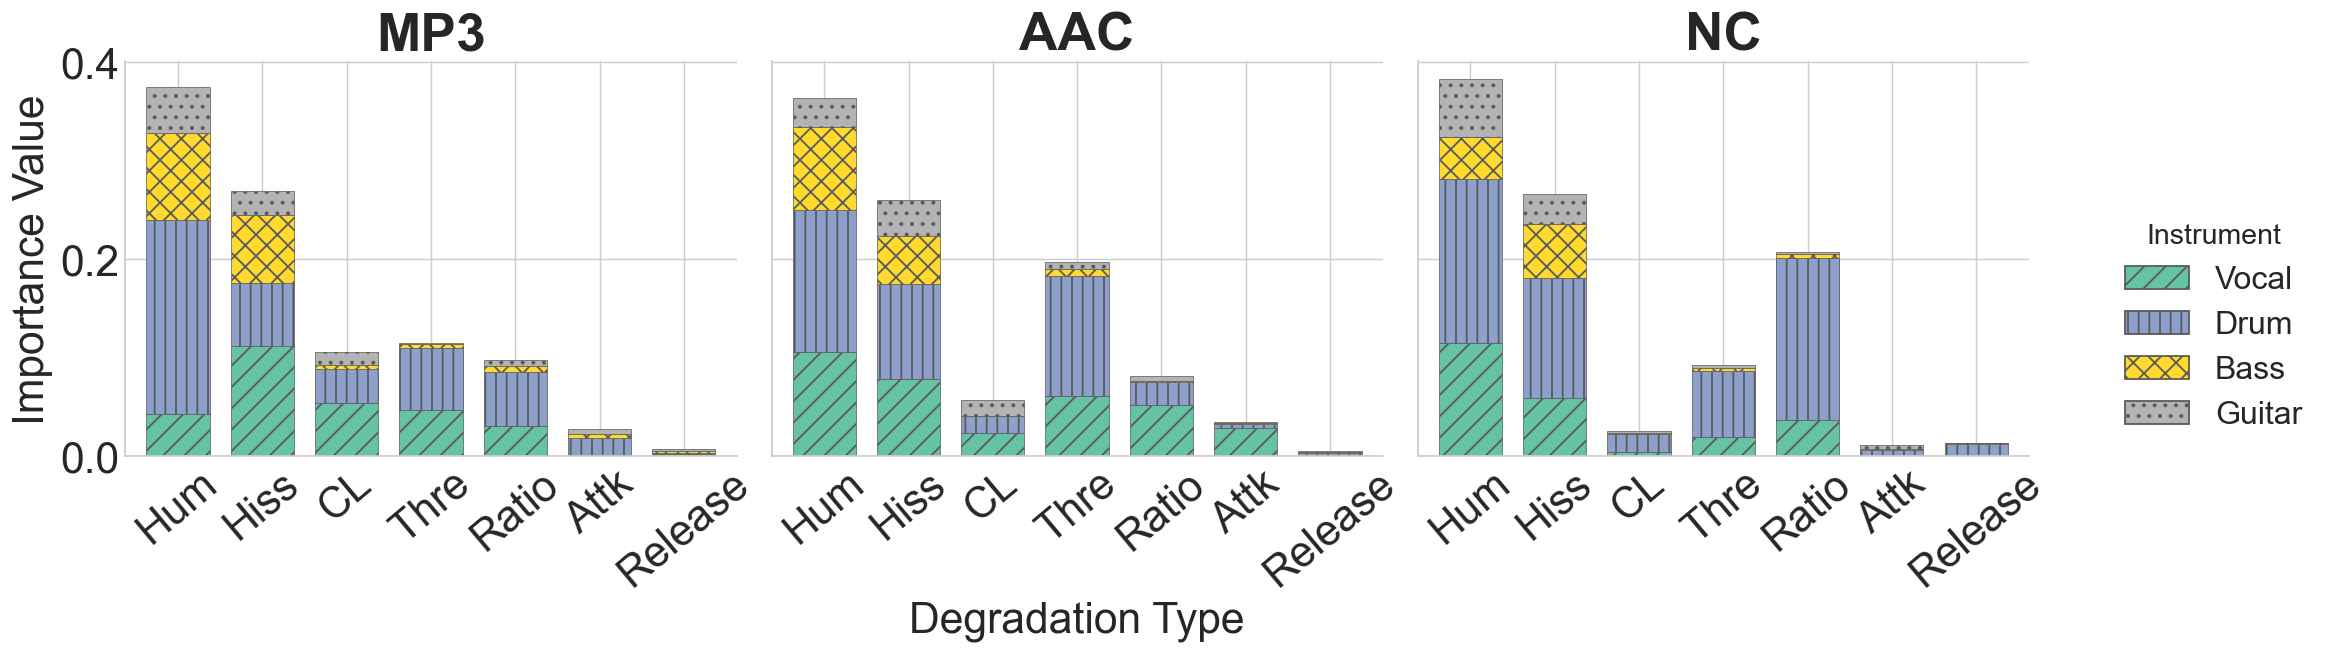

In [33]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# -----------------------------
# Font configuration
# -----------------------------
FONT = {
    "title": 30,
    "label": 24,
    "tick": 24,
    "legend": 18,
    "legend_title": 16,
}

codec_name_map = {
    "mp3": "MP3",
    "aac": "AAC",
    "nc": "EnCodec",
}


# -----------------------------
# Figure
# -----------------------------
fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 5),
    dpi=128,
    sharey=True,
    sharex=True,
    constrained_layout=True
)

instrument_hatches = {
    "Vocal":  "//",
    "Drum":   "||",
    "Bass":   "xx",
    "Guitar": "..",
}

legend_handles = None

for i, (ax, codec_name) in enumerate(zip(axes, datasets.keys())):
    matrix = inst_param_matrices[codec_name]

    # Normalise within codec
    matrix_norm = matrix / matrix.values.sum()

    matrix_norm.T.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        colormap="Set2",
        legend=False,
        width=0.75
    )

    # Apply hatching
    for container, inst in zip(ax.containers, matrix_norm.index):
        for bar in container:
            bar.set_hatch(instrument_hatches.get(inst, ""))
            bar.set_edgecolor("0.35")
            bar.set_linewidth(0.4)

    # Titles and axis labels
    display_name = codec_name_map.get(codec_name, codec_name)
    ax.set_title(display_name, fontweight="bold", fontsize=FONT["title"])
    

    if i == 0:
        ax.set_ylabel("Importance Value", fontsize=FONT["label"])
    else:
        ax.set_ylabel("")

    if i == 1:
        ax.set_xlabel("Degradation Type", fontsize=FONT["label"])
    else:
        ax.set_xlabel("")

    # Tick font size and rotation
    ax.tick_params(axis="x", labelrotation=40, labelsize=FONT["tick"])
    ax.tick_params(axis="y", labelsize=FONT["tick"])

    # Cleaner frame
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Build legend once
    if legend_handles is None:
        legend_handles = [
            Patch(
                facecolor=container.patches[0].get_facecolor(),
                hatch=instrument_hatches.get(inst, ""),
                edgecolor="0.35",
                label=inst
            )
            for container, inst in zip(ax.containers, matrix_norm.index)
        ]

# Shared legend
fig.legend(
    handles=legend_handles,
    title="Instrument",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=FONT["legend"],
    title_fontsize=FONT["legend_title"]
)

plt.show()